In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

In [3]:
!pip install kaggle==1.5.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.5.12-py3-none-any.whl size=73026 sha256=8e285ccc1ba6248b62509276784d6915b4b30fa833329f4ca2ee602b7a20eef6
  Stored in directory: /root/.cache/pip/wheels/2e/27/39/f44e52756a6407b444143f233abe9fda0e18a23e8b20e0cd1c
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.6.17
    Uninstalling kaggle-1.6.17:
      Successfully uninstalled kaggle-1.6.17


In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pratikharibhakta","key":"74f8d8137964693835e78075b5425491"}'}

In [5]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

In [6]:
!kaggle datasets download kritikseth/fruit-and-vegetable-image-recognition

100% 1.98G/1.98G [00:20<00:00, 149MB/s]
100% 1.98G/1.98G [00:20<00:00, 102MB/s]


In [7]:
!unzip fruit-and-vegetable-image-recognition.zip

Archive:  fruit-and-vegetable-image-recognition.zip
  inflating: test/apple/Image_1.jpg  
  inflating: test/apple/Image_10.jpg  
  inflating: test/apple/Image_2.jpg  
  inflating: test/apple/Image_3.jpg  
  inflating: test/apple/Image_4.jpg  
  inflating: test/apple/Image_5.jpg  
  inflating: test/apple/Image_6.JPG  
  inflating: test/apple/Image_7.jpg  
  inflating: test/apple/Image_8.jpg  
  inflating: test/apple/Image_9.jpg  
  inflating: test/banana/Image_1.jpg  
  inflating: test/banana/Image_10.jpg  
  inflating: test/banana/Image_2.jpg  
  inflating: test/banana/Image_3.jpg  
  inflating: test/banana/Image_4.jpg  
  inflating: test/banana/Image_5.jpg  
  inflating: test/banana/Image_6.jpg  
  inflating: test/banana/Image_8.jpg  
  inflating: test/banana/Image_9.jpg  
  inflating: test/beetroot/Image_1.jpg  
  inflating: test/beetroot/Image_10.jpg  
  inflating: test/beetroot/Image_2.jpg  
  inflating: test/beetroot/Image_3.jpg  
  inflating: test/beetroot/Image_4.jpg  
  inflati

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print(tf.__version__)

2.18.0


In [9]:
# Create a list with the filepaths for training and testing
train_dir = Path('/content/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

In [10]:
test_dir = Path('/content/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))

In [11]:
val_dir = Path('/content/validation')
val_filepaths = list(test_dir.glob(r'**/*.jpg'))

In [12]:
def image_processing(filepath):
    """ Create a DataFrame with the filepath and the labels of the pictures
    """

    labels = [str(filepath[i]).split("/")[-2] \
              for i in range(len(filepath))]

    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')

    # Concatenate filepaths and labels
    df = pd.concat([filepath, labels], axis=1)

    # Shuffle the DataFrame and reset index
    df = df.sample(frac=1).reset_index(drop = True)

    return df

In [13]:
train_df = image_processing(train_filepaths)
test_df = image_processing(test_filepaths)
val_df = image_processing(val_filepaths)

In [14]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

-- Training set --

Number of pictures: 2780

Number of different labels: 36

Labels: ['orange' 'cabbage' 'beetroot' 'cauliflower' 'potato' 'carrot' 'ginger'
 'pineapple' 'lettuce' 'raddish' 'kiwi' 'pomegranate' 'garlic' 'peas'
 'corn' 'sweetpotato' 'sweetcorn' 'watermelon' 'eggplant' 'tomato'
 'grapes' 'soy beans' 'chilli pepper' 'lemon' 'paprika' 'capsicum'
 'bell pepper' 'spinach' 'onion' 'turnip' 'banana' 'pear' 'jalepeno'
 'apple' 'cucumber' 'mango']


In [15]:
train_df.head(5)

,Filepath,Label
0,/content/train/orange/Image_36.jpg,orange
1,/content/train/cabbage/Image_61.jpg,cabbage
2,/content/train/beetroot/Image_68.jpg,beetroot
3,/content/train/cauliflower/Image_36.jpg,cauliflower
4,/content/train/potato/Image_98.jpg,potato


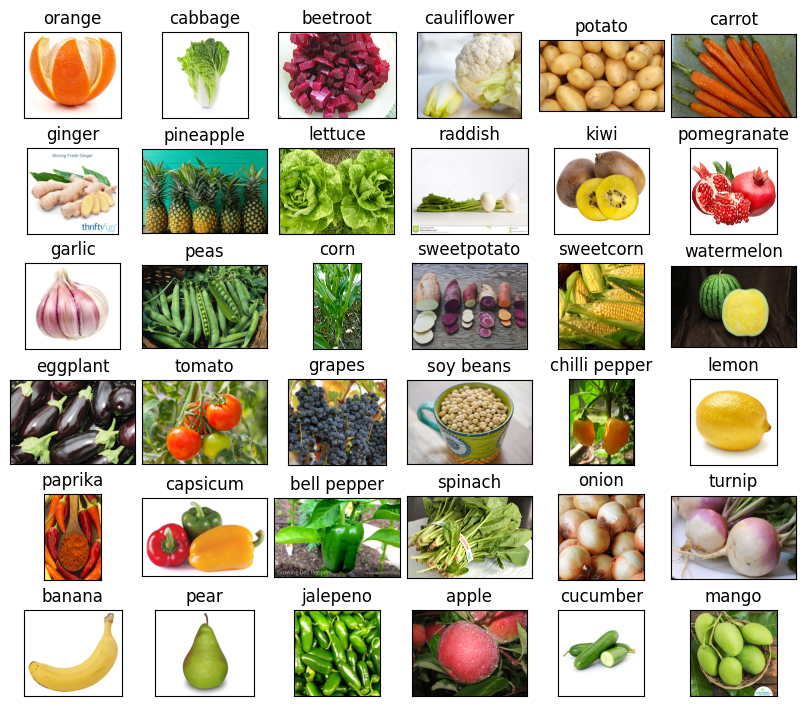

In [16]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(8, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.Filepath[i]))
    ax.set_title(df_unique.Label[i], fontsize = 12)
plt.tight_layout(pad=0.5)
plt.show()

In [17]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [18]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 2780 validated image filenames belonging to 36 classes.


In [19]:
val_images = train_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 334 validated image filenames belonging to 36 classes.


In [20]:
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 334 validated image filenames belonging to 36 classes.


In [21]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(36, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.3292 - loss: 2.6414 - val_accuracy: 0.8802 - val_loss: 0.4635
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.8177 - loss: 0.5764 - val_accuracy: 0.8982 - val_loss: 0.2889
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.8925 - loss: 0.3448 - val_accuracy: 0.9371 - val_loss: 0.2093
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9340 - loss: 0.2217 - val_accuracy: 0.9401 - val_loss: 0.1765
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.9604 - loss: 0.1521 - val_accuracy: 0.9671 - val_loss: 0.1502


In [23]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)
# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred1 = [labels[k] for k in pred]
pred1

11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


['turnip',
 'peas',
 'chilli pepper',
 'soy beans',
 'beetroot',
 'jalepeno',
 'cauliflower',
 'carrot',
 'garlic',
 'sweetcorn',
 'cabbage',
 'onion',
 'sweetcorn',
 'onion',
 'spinach',
 'cabbage',
 'pineapple',
 'apple',
 'pomegranate',
 'onion',
 'sweetpotato',
 'watermelon',
 'jalepeno',
 'paprika',
 'watermelon',
 'lemon',
 'spinach',
 'kiwi',
 'lemon',
 'watermelon',
 'chilli pepper',
 'turnip',
 'kiwi',
 'mango',
 'banana',
 'beetroot',
 'paprika',
 'beetroot',
 'beetroot',
 'paprika',
 'peas',
 'grapes',
 'cabbage',
 'cabbage',
 'bell pepper',
 'soy beans',
 'capsicum',
 'capsicum',
 'jalepeno',
 'chilli pepper',
 'onion',
 'raddish',
 'pear',
 'pear',
 'beetroot',
 'bell pepper',
 'pomegranate',
 'jalepeno',
 'beetroot',
 'tomato',
 'pomegranate',
 'corn',
 'cauliflower',
 'capsicum',
 'eggplant',
 'cauliflower',
 'onion',
 'grapes',
 'pineapple',
 'eggplant',
 'eggplant',
 'jalepeno',
 'potato',
 'spinach',
 'bell pepper',
 'sweetcorn',
 'chilli pepper',
 'sweetcorn',
 'carr

In [ ]:
def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]
    return res

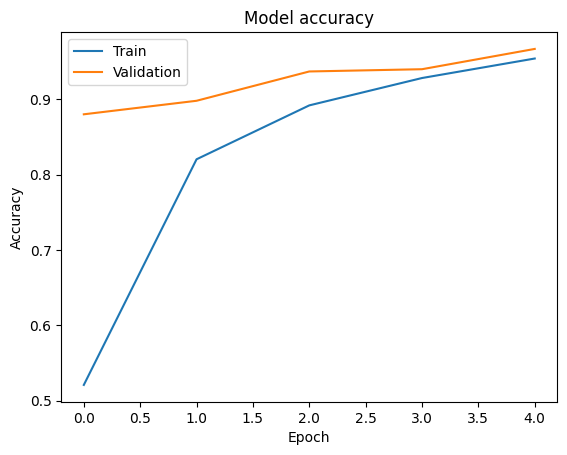

In [24]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

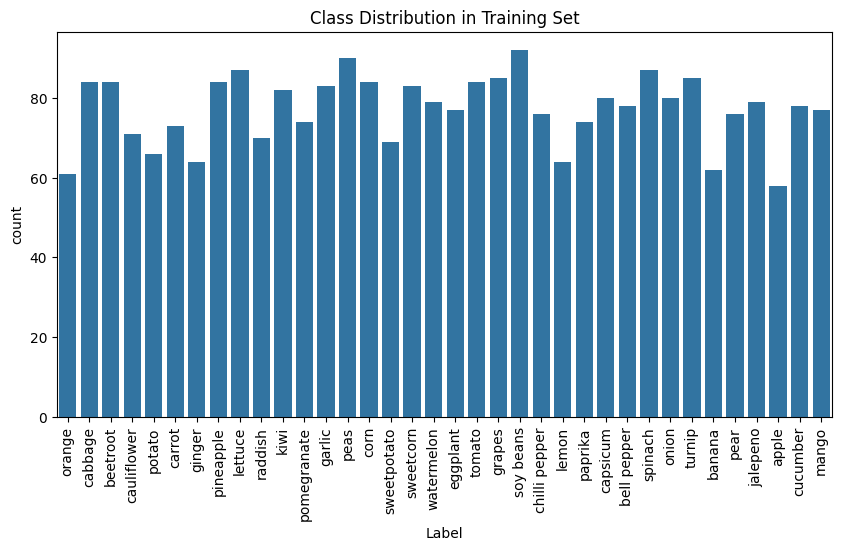

In [26]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Label', data=train_df)
plt.xticks(rotation=90)
plt.title('Class Distribution in Training Set')
plt.show()

In [ ]:
img = output('/content/train/pineapple/Image_1.jpg')
img

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


'pineapple'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


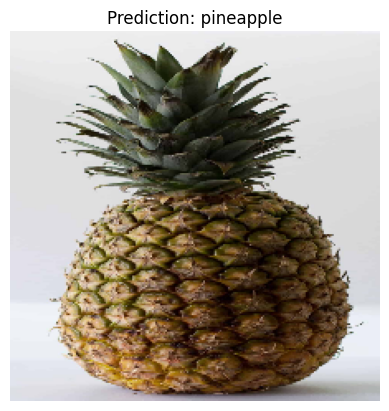

'pineapple'

In [ ]:
from tensorflow.keras.preprocessing.image import load_img

def output(location):
    # Load and preprocess the image
    img_original = load_img(location, target_size=(224, 224, 3))
    img = img_to_array(img_original)
    img = img / 255
    img = np.expand_dims(img, [0])

    # Make prediction
    answer = model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]

    # Display the image and prediction
    plt.imshow(img_original)
    plt.title(f"Prediction: {res}")
    plt.axis('off')  # Turn off axis labels
    plt.show()

    return res

img = output('/content/train/pineapple/Image_1.jpg')
img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


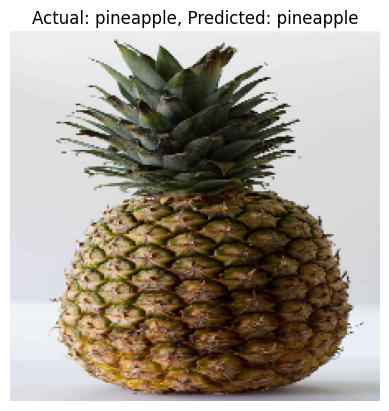

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


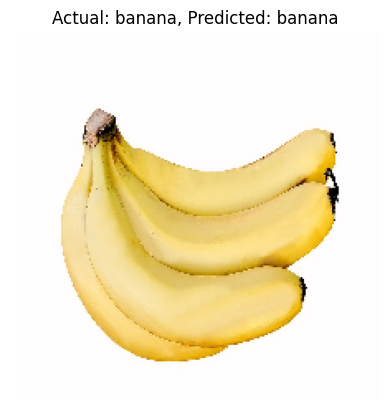

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


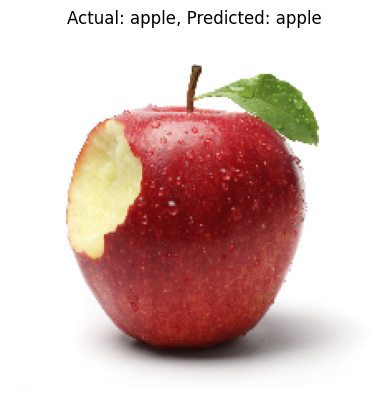

In [ ]:
from tensorflow.keras.preprocessing.image import load_img
import os

def output(locations):
    for location in locations:
        # Get the actual label from the file path
        actual_label = os.path.basename(os.path.dirname(location))

        # Load and preprocess the image
        img_original = load_img(location, target_size=(224, 224, 3))
        img = img_to_array(img_original)
        img = img / 255
        img = np.expand_dims(img, [0])

        # Make prediction
        answer = model.predict(img)
        y_class = answer.argmax(axis=-1)
        y = " ".join(str(x) for x in y_class)
        y = int(y)
        predicted_label = labels[y]

        # Display the image and prediction
        plt.figure()
        plt.imshow(img_original)
        plt.title(f"Actual: {actual_label}, Predicted: {predicted_label}")
        plt.axis('off')
        plt.show()

# Provide a list of image paths
image_paths = [
    '/content/train/pineapple/Image_1.jpg',
    '/content/train/banana/Image_1.jpg',
    '/content/train/apple/Image_1.jpg',
    # ...
]

output(image_paths)

In [ ]:
model.save('FV.h5')